In [1]:
from few.utils.Extra_for_project.flux_calculations import (compare, kerrecceqA, nex, 
nex_pedot, few_pedot, nex_ELdot, few_ELdot)
import numpy as np
import matplotlib.pyplot as plt
from few.utils.geodesic import get_separatrix
from few.utils.mappings.kerrecceq import DELTAPMAX_REGIONC,DELTAPMIN_REGIONC

KerrEccEqFluxData_nex.h5
All good
KerrEccEqFluxData_nex.h5
KerrEccEqFluxData_nex.h5
All good


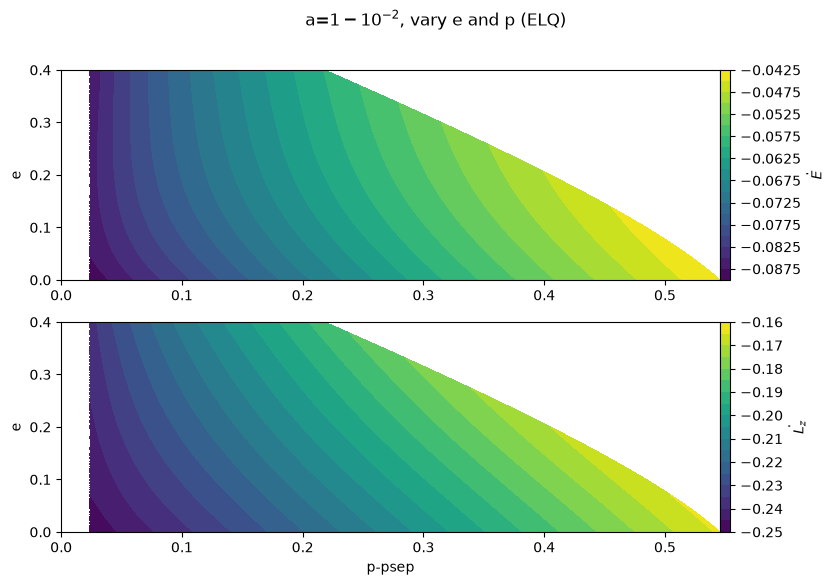

In [3]:
x=1
n=2
a=1-10**(-n)
n1,n2 =1000,1000

e = np.linspace(0, 0.4, n1)
psep_min = min(get_separatrix(a,e,x))
p= np.linspace(1,2,n2)

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)

Z = nex_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten())   #flux takes apex, spits out pdot, edot, Edot,Ldot

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)

Z_p = Z[0].reshape(n1,n2)
Z_e = Z[1].reshape(n1,n2)

Zp_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p, np.nan)
Ze_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e, np.nan)


fig, ax = plt.subplots(2,1,figsize = (10,6))

cf1 = ax[0].contourf(P-PSEP, E, Zp_masked, levels=20, cmap="viridis")
fig.colorbar(cf1, ax=ax[0], label=r"$\dot{E}$",pad = 0)
cf2 = ax[1].contourf(P-PSEP, E, Ze_masked, levels=20, cmap="viridis")
fig.colorbar(cf2, ax=ax[1], label=r"$\dot{L_{z}}$",pad = 0)

ax[0].set_xlim(0)
ax[1].set_xlim(0)

ax[0].set_ylabel("e")

ax[1].set_xlabel("p-psep")
ax[1].set_ylabel("e")

#ax[0].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax[1].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")
plt.suptitle(rf"a=$1-10^{{-{n}}}$, vary e and p (ELQ)")
plt.show()
#fig.savefig(f"contourplot_e_vs_p_n={n}_compare_with_few_ELQ.png", dpi=300, bbox_inches="tight")

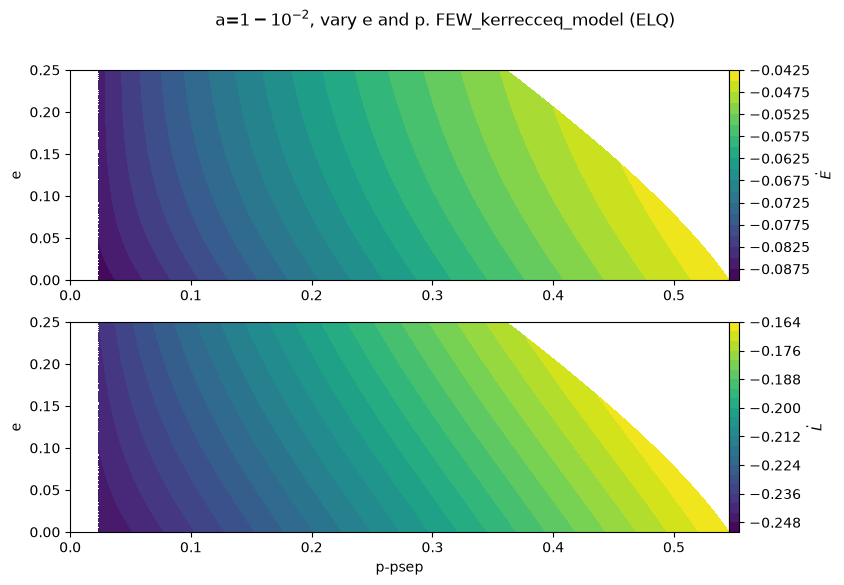

In [4]:
x=1
n=2
a=1-10**(-n)
n1,n2 =1000,1000

e = np.linspace(0, 0.25, n1)
psep_min = min(get_separatrix(a,e,x))
p= np.linspace(1,2,n2) #######Change  pmin to further out to see behaviour away from separatrix better

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)

Z = few_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten())

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)

Z_p = Z[0].reshape(n1,n2)
Z_e = Z[1].reshape(n1,n2)

Zp_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p, np.nan)
Ze_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e, np.nan)


fig, ax = plt.subplots(2,1,figsize = (10,6))

cf1 = ax[0].contourf(P-PSEP, E, Zp_masked, levels=20, cmap="viridis")
fig.colorbar(cf1, ax=ax[0], label=r"$\dot{E}$",pad = 0)
cf2 = ax[1].contourf(P-PSEP, E, Ze_masked, levels=20, cmap="viridis")
fig.colorbar(cf2, ax=ax[1], label=r"$\dot{L}$",pad = 0)

ax[0].set_xlim(0)
ax[1].set_xlim(0)

ax[0].set_ylabel("e")

ax[1].set_xlabel("p-psep")
ax[1].set_ylabel("e")

#ax[0].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax[1].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")
plt.suptitle(rf"a=$1-10^{{-{n}}}$, vary e and p. FEW_kerrecceq_model (ELQ)")
plt.show()
#fig.savefig(f"contourplot_e_vs_p_n={n}_FEW_ELQ.png", dpi=300, bbox_inches="tight")

## Directly compare FEW and NEX data

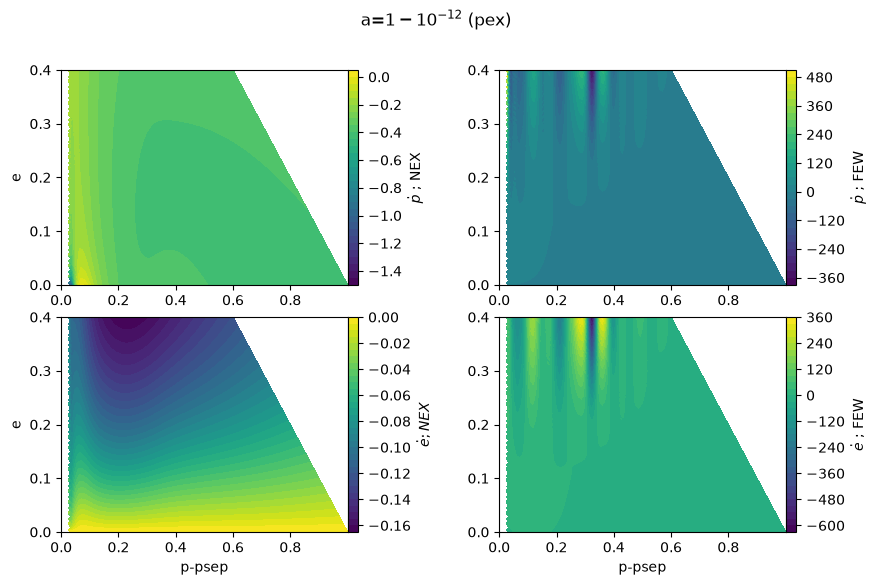

In [5]:
x=1
n=12
a=1-10**(-n)
n1,n2 =100,100

e = np.linspace(0, 0.4, n1)
psep_min = min(get_separatrix(a,e,x))
p= np.linspace(1,2,n2)

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)
PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)


#Add near-extremal data
Z_nex = nex_pedot(A.flatten(),P.flatten(),E.flatten(),X.flatten())   #flux takes apex, spits out pdot, edot, Edot,Ldot

Z_p_nex = Z_nex[0].reshape(n1,n2)
Z_e_nex = Z_nex[1].reshape(n1,n2)

Zp_nex_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p_nex, np.nan)
Ze_nex_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e_nex, np.nan)

#Add FEW data
Z_few = few_pedot(A.flatten(),P.flatten(),E.flatten(),X.flatten())   #flux takes apex, spits out pdot, edot, Edot,Ldot

Z_p_few = Z_few[0].reshape(n1,n2)
Z_e_few = Z_few[1].reshape(n1,n2)

Zp_few_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p_few, np.nan)
Ze_few_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e_few, np.nan)


fig, ax = plt.subplots(2,2,figsize = (10,6))
lvls = 33

cf1 = ax[0,0].contourf(P-PSEP, E, Zp_nex_masked, levels=lvls, cmap="viridis")
fig.colorbar(cf1, ax=ax[0,0], label=r"$\dot{p}$ ; NEX",pad = 0)
cf2 = ax[1,0].contourf(P-PSEP, E, Ze_nex_masked, levels=lvls, cmap="viridis")
fig.colorbar(cf2, ax=ax[1,0], label=r"$\dot{e} ; NEX$",pad = 0)

cf3 = ax[0,1].contourf(P-PSEP, E, Zp_few_masked, levels=lvls, cmap="viridis")
fig.colorbar(cf3, ax=ax[0,1], label=r"$\dot{p}$ ; FEW",pad = 0)
cf4 = ax[1,1].contourf(P-PSEP, E, Ze_few_masked, levels=lvls, cmap="viridis")
fig.colorbar(cf4, ax=ax[1,1], label=r"$\dot{e}$ ; FEW",pad = 0)

ax[0,0].set_xlim(0)
ax[1,0].set_xlim(0)
ax[0,1].set_xlim(0)
ax[1,1].set_xlim(0)

ax[0,0].set_ylabel("e")

ax[1,0].set_xlabel("p-psep")
ax[1,1].set_xlabel("p-psep")
ax[1,0].set_ylabel("e")

plt.subplots_adjust(
    wspace=0.3,  
    hspace=0.15
)

#ax[0].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax[1].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")
plt.suptitle(rf"a=$1-10^{{-{n}}}$ (pex)")
plt.show()
#fig.savefig(f"contourplot_e_vs_p_n={n}_compare_with_few_ELQ.png", dpi=300, bbox_inches="tight")


In [11]:
np.nanmax(Zp_nex_masked)

np.float64(0.010094980728247032)

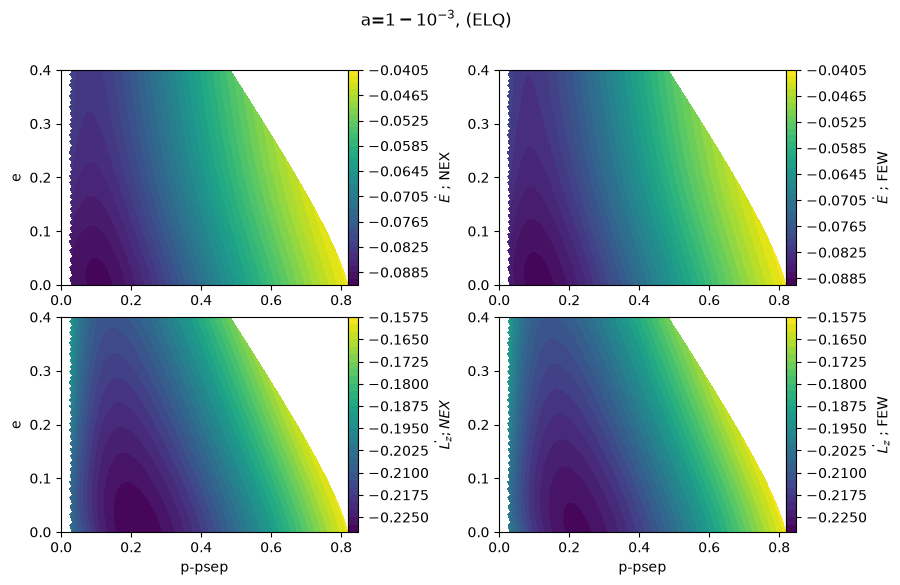

In [10]:
x=1
n=3
a=1-10**(-n)
n1,n2 =100,100

e = np.linspace(0, 0.4, n1)
psep_min = min(get_separatrix(a,e,x))
p= np.linspace(1,2,n2)

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)
PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)


#Add near-extremal data
Z_nex = nex_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten())   #flux takes apex, spits out pdot, edot, Edot,Ldot

Z_p_nex = Z_nex[0].reshape(n1,n2)
Z_e_nex = Z_nex[1].reshape(n1,n2)

Zp_nex_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p_nex, np.nan)
Ze_nex_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e_nex, np.nan)

#Add FEW data
Z_few = few_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten())   #flux takes apex, spits out pdot, edot, Edot,Ldot

Z_p_few = Z_few[0].reshape(n1,n2)
Z_e_few = Z_few[1].reshape(n1,n2)

Zp_few_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p_few, np.nan)
Ze_few_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e_few, np.nan)


fig, ax = plt.subplots(2,2,figsize = (10,6))
lvls =33

cf1 = ax[0,0].contourf(P-PSEP, E, Zp_nex_masked, levels=lvls, cmap="viridis")
fig.colorbar(cf1, ax=ax[0,0], label=r"$\dot{E}$ ; NEX",pad = 0)
cf2 = ax[1,0].contourf(P-PSEP, E, Ze_nex_masked, levels=lvls, cmap="viridis")
fig.colorbar(cf2, ax=ax[1,0], label=r"$\dot{L_z} ; NEX$",pad = 0)

cf3 = ax[0,1].contourf(P-PSEP, E, Zp_few_masked, levels=lvls, cmap="viridis")
fig.colorbar(cf3, ax=ax[0,1], label=r"$\dot{E}$ ; FEW",pad = 0)
cf4 = ax[1,1].contourf(P-PSEP, E, Ze_few_masked, levels=lvls, cmap="viridis")
fig.colorbar(cf4, ax=ax[1,1], label=r"$\dot{L_z}$ ; FEW",pad = 0)

ax[0,0].set_xlim(0)
ax[1,0].set_xlim(0)
ax[0,1].set_xlim(0)
ax[1,1].set_xlim(0)

ax[0,0].set_ylabel("e")

ax[1,0].set_xlabel("p-psep")
ax[1,1].set_xlabel("p-psep")
ax[1,0].set_ylabel("e")

plt.subplots_adjust(
    wspace=0.3,  
    hspace=0.15
)

#ax[0].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax[1].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")
plt.suptitle(rf"a=$1-10^{{-{n}}}$, (ELQ)")
plt.show()
#fig.savefig(f"contourplot_e_vs_p_n={n}_compare_with_few_ELQ.png", dpi=300, bbox_inches="tight")

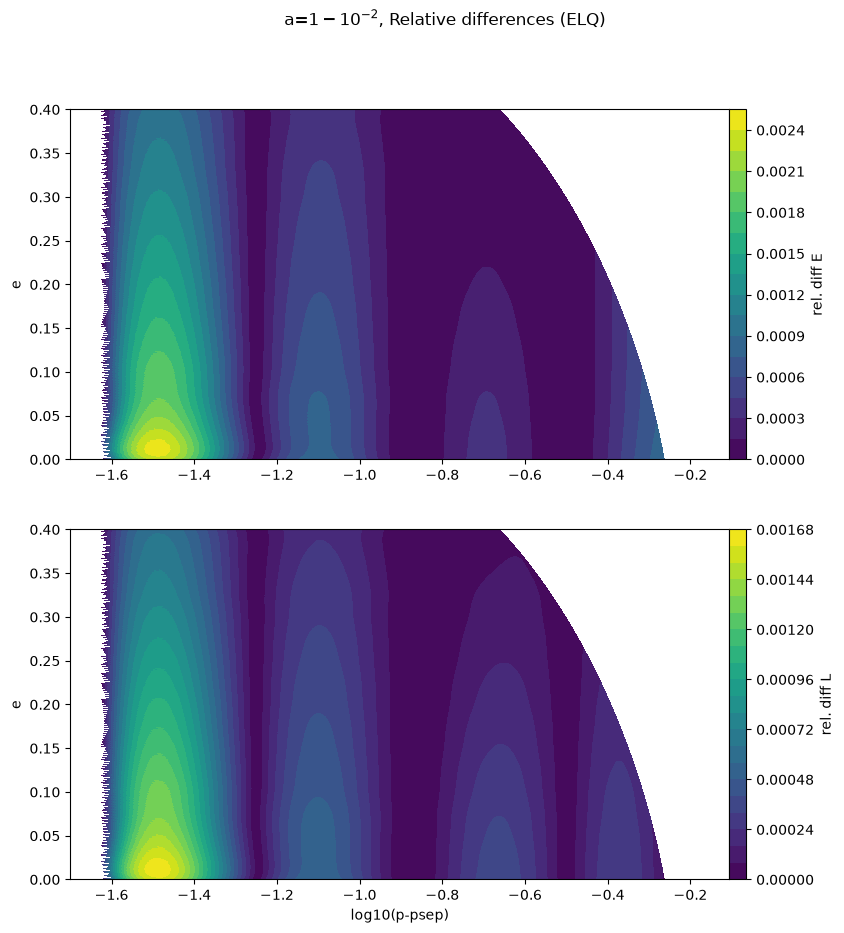

In [9]:
x=1
n=2
a=1-10**(-n)
n1,n2 =500,500

e = np.linspace(0, 0.4, n1)
psep_min = min(get_separatrix(a,e,x))
p= np.linspace(1,2,n2)

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)

Z_few = few_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten())   #flux takes apex, spits out pdot, edot, Edot,Ldot
Z_nex = nex_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten()) 

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)

Z_nex_p = Z_nex[0].reshape(n1,n2)
Z_nex_e = Z_nex[1].reshape(n1,n2)
Z_few_p = Z_few[0].reshape(n1,n2)
Z_few_e = Z_few[1].reshape(n1,n2)

Zp_nex_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_nex_p, np.nan)
Ze_nex_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_nex_e, np.nan)
Zp_few_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_few_p, np.nan)
Ze_few_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_few_e, np.nan)


rel_diff_E = np.abs((Zp_nex_masked - Zp_few_masked)/(Zp_nex_masked))
rel_diff_L = np.abs((Ze_nex_masked - Ze_few_masked)/(Ze_nex_masked))


fig, ax = plt.subplots(2,1,figsize = (10,10))

cf1 = ax[0].contourf(np.log10(np.abs(P-PSEP)), E, rel_diff_E, levels=20, cmap="viridis")
fig.colorbar(cf1, ax=ax[0], label=r"rel. diff E",pad = 0)
cf2 = ax[1].contourf(np.log10(np.abs(P-PSEP)), E, rel_diff_L, levels=20, cmap="viridis")
fig.colorbar(cf2, ax=ax[1], label=r"rel. diff L",pad = 0)

ax[0].set_xlim(-1.7)
ax[1].set_xlim(-1.7)

ax[0].set_ylabel("e")

ax[1].set_xlabel("log10(p-psep)")
ax[1].set_ylabel("e")

#ax[0].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax[1].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")
plt.suptitle(rf"a=$1-10^{{-{n}}}$, Relative differences (ELQ)")
plt.show()
#fig.savefig(f"contourplot_e_vs_p_n={n}_compare_with_few_ELQ.png", dpi=300, bbox_inches="tight")

/tmp/ipykernel_2983/989089840.py:32: RuntimeWarning: invalid value encountered in divide
  rel_diff_e = np.abs((Ze_nex_masked - Ze_few_masked)/(Ze_nex_masked))


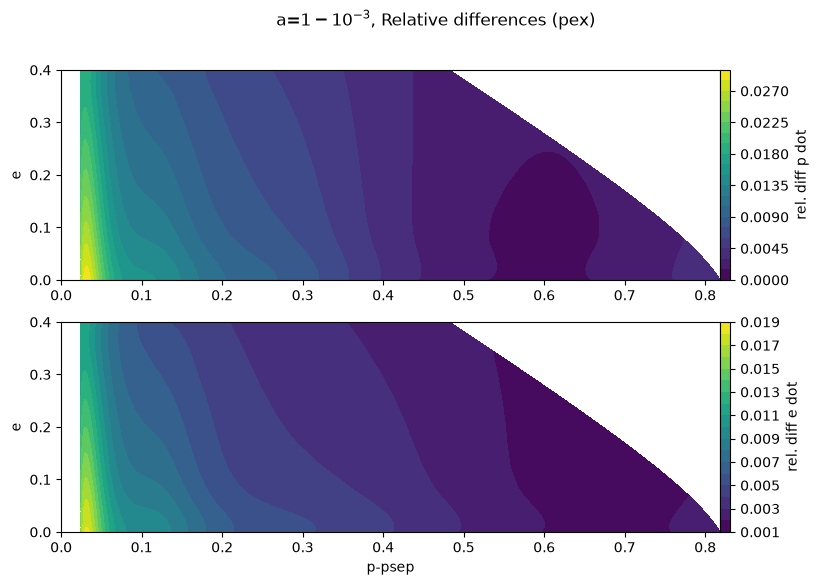

In [50]:
x=1
n=3
a=1-10**(-n)
n1,n2 =500,500

e = np.linspace(0, 0.4, n1)
psep_min = min(get_separatrix(a,e,x))
p= np.linspace(1,2,n2)

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)

Z_few = few_pedot(A.flatten(),P.flatten(),E.flatten(),X.flatten())   #flux takes apex, spits out pdot, edot, Edot,Ldot
Z_nex = nex_pedot(A.flatten(),P.flatten(),E.flatten(),X.flatten()) 

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)

Z_nex_p = Z_nex[0].reshape(n1,n2)
Z_nex_e = Z_nex[1].reshape(n1,n2)
Z_few_p = Z_few[0].reshape(n1,n2)
Z_few_e = Z_few[1].reshape(n1,n2)

Zp_nex_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_nex_p, np.nan)
Ze_nex_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_nex_e, np.nan)
Zp_few_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_few_p, np.nan)
Ze_few_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_few_e, np.nan)


rel_diff_p = np.abs((Zp_nex_masked - Zp_few_masked)/(Zp_nex_masked))
rel_diff_e = np.abs((Ze_nex_masked - Ze_few_masked)/(Ze_nex_masked))


fig, ax = plt.subplots(2,1,figsize = (10,6))

cf1 = ax[0].contourf(P-PSEP, E, rel_diff_E, levels=20, cmap="viridis")
fig.colorbar(cf1, ax=ax[0], label=r"rel. diff p dot",pad = 0)
cf2 = ax[1].contourf(P-PSEP, E, rel_diff_L, levels=20, cmap="viridis")
fig.colorbar(cf2, ax=ax[1], label=r"rel. diff e dot",pad = 0)

ax[0].set_xlim(0)
ax[1].set_xlim(0)

ax[0].set_ylabel("e")

ax[1].set_xlabel("p-psep")
ax[1].set_ylabel("e")

#ax[0].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax[1].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")
plt.suptitle(rf"a=$1-10^{{-{n}}}$, Relative differences (pex)")
plt.show()
#fig.savefig(f"contourplot_e_vs_p_n={n}_compare_with_few_ELQ.png", dpi=300, bbox_inches="tight")